# TabPFN for Uplift Modeling with Meta-Learners (LaLonde NSW-RE74)

This notebook evaluates whether TabPFN can improve uplift modeling performance when used inside meta-learners compared to traditional models (LinearRegression, LightGBM) and a standalone causal model (CausalPFN).

**Dataset**: NSW-RE74 (National Supported Work Demonstration) — a randomized controlled trial with continuous income outcome (RE78).
- 445 samples (185 treated + 260 control), 8 covariates, outcome = earnings in 1978
- RE78 has a point mass at zero (~31% of participants had zero earnings)

**Evaluation protocol**:
- 50 repeated stratified train/test splits (80/20, stratified on T × binarised Y: treatment × zero/positive earnings)
- All models trained on training set only, evaluated on held-out test set
- R-learner (NonParamDML) and DR-learner (LinearDRLearner) use 5-fold cross-fitting within the training data for nuisance estimation
- LightGBM hyperparameters tuned once per split via RandomizedSearchCV (15 iterations, 3-fold CV)
- TabPFN-HPO uses `TunedTabPFNRegressor`/`TunedTabPFNClassifier` with Bayesian HPO (n_trials=20) for S, T, X-learners

**Metrics** (all computed on the test set per split):
- **AUQC**: Area between the Qini curve and its diagonal (the random-model baseline). Expected value under a random CATE ranking is 0 by construction; significance test checks whether the 95% CI excludes zero.
- **Policy Gain @k%** (k = 10, 20, 30, 40): IPW policy value for treating the top-k% minus the random k% baseline — already measures improvement over random targeting

**Models**:
- Meta-learners: S, T, X, R (NonParamDML, cv=5), DR (LinearDRLearner, cv=5)
- Base models: LinearRegression, LightGBM (tuned), TabPFN, TabICL, TabPFN-HPO (S/T/X only)
- Standalone: CausalForestDML (cv=5, LightGBM nuisance), CausalPFN

## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as st
import pickle
from collections import defaultdict
from datetime import datetime
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, StratifiedKFold, KFold
from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from tabpfn import TabPFNRegressor, TabPFNClassifier
from tabpfn_extensions.hpo import TunedTabPFNRegressor, TunedTabPFNClassifier
from tabicl import TabICLRegressor, TabICLClassifier
from econml.metalearners import SLearner, TLearner, XLearner
from econml.dml import NonParamDML, CausalForestDML
from econml.dr import LinearDRLearner
import matplotlib.pyplot as plt
import warnings
import torch
import os

from causalpfn import CATEEstimator
from causalpfn.evaluation import get_qini_curve as _get_qini_curve

def _compute_auqc(qini_curve):
    n = len(qini_curve)
    phi = np.linspace(1/n, 1.0, n)
    diagonal = phi * qini_curve[-1]
    return np.trapz(qini_curve - diagonal, phi)

def get_qini_curve(T, Y, cate):
    # _compute_auqc always computes the diagonal-subtracted area
    curve, _ = _get_qini_curve(T, Y, cate, normalize=False)
    return curve, _compute_auqc(curve)

# Device detection (CUDA > MPS > CPU)
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f"TabPFN device: {device}")

# CausalPFN does not support MPS
causalpfn_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"CausalPFN device: {causalpfn_device}")

# TabICL does not support MPS — fall back to CPU
tabicl_device = "cpu" if device == "mps" else device
print(f"TabICL device: {tabicl_device}")

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TABPFN_NO_TELEMETRY_PROMPT"] = "1"

# Results output directory — timestamped to avoid overwriting previous runs
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
RESULTS_DIR = os.path.join('results', RUN_ID)
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Results directory: {RESULTS_DIR}")

np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)  # no-op if no CUDA
warnings.filterwarnings("ignore")

TabPFN device: mps
CausalPFN device: cpu
TabICL device: cpu
Results directory: results/20260313_192143


## 2. Helper Functions

LightGBM tuning via `RandomizedSearchCV` (20 combinations, 3-fold CV, 9 hyperparameters). IPW-based policy value estimation for top-k% targeting. Qini curve interpolation. AUQC is computed as the area between the Qini curve and its diagonal (the random-model baseline), so its expected value under a random CATE ranking is 0 by construction.

In [2]:
# --- LightGBM hyperparameter tuning ---

# ── Strong grid ───────────────────────────────────────────────────────────────
# Search over a fixed discrete grid (N_ITER_STRONG random draws via RandomizedSearchCV).
# Two-phase: (1) tune with n_estimators_search trees for speed, (2) refit best params
# with n_estimators_final trees for final quality.
# _tune_reg_arm uses KFold (not StratifiedKFold) since per-arm subsets are single-class.
LGBM_GRID_STRONG = {
    'max_depth':         [3, 5, 7, 9],
    'num_leaves':        [15, 31, 63, 127],
    'learning_rate':     [0.01, 0.05, 0.1],
    'min_child_samples': [5, 10, 20, 50],
    'subsample':         [0.7, 0.85, 1.0],
    'colsample_bytree':  [0.7, 0.85, 1.0],
    'reg_lambda':        [0, 0.1, 1, 10],
}
N_ITER_STRONG = 15  # RandomizedSearchCV draws

# ── Core tuner for pooled data — used by S, R, DR learners ───────────────────
def _tune_reg(X, y, stratify, grid, n_iter=None, n_estimators_search=200,
              n_estimators_final=1000, seed=42):
    # Phase 1: search with fewer trees for faster CV
    base = LGBMRegressor(n_estimators=n_estimators_search, random_state=seed, verbose=-1)
    cv = list(StratifiedKFold(n_splits=3, shuffle=True, random_state=seed).split(X, stratify))
    Search = RandomizedSearchCV if n_iter else GridSearchCV
    kw = dict(n_iter=n_iter, random_state=seed) if n_iter else {}
    search = Search(base, grid, scoring='neg_mean_squared_error', cv=cv, n_jobs=-1, **kw)
    search.fit(X, y)
    # Phase 2: refit best hyperparams with full tree budget
    best_params = search.best_params_
    final_model = LGBMRegressor(n_estimators=n_estimators_final, random_state=seed,
                                verbose=-1, **best_params)
    final_model.fit(X, y)
    return final_model

def _tune_cls(X, t, grid, n_iter=None, n_estimators_search=200,
              n_estimators_final=1000, seed=42):
    # Phase 1: search with fewer trees
    base = LGBMClassifier(n_estimators=n_estimators_search, random_state=seed, verbose=-1)
    cv = list(StratifiedKFold(n_splits=3, shuffle=True, random_state=seed).split(X, t))
    Search = RandomizedSearchCV if n_iter else GridSearchCV
    kw = dict(n_iter=n_iter, random_state=seed) if n_iter else {}
    search = Search(base, grid, scoring='neg_log_loss', cv=cv, n_jobs=-1, **kw)
    search.fit(X, t)
    # Phase 2: refit with full tree budget
    best_params = search.best_params_
    final_model = LGBMClassifier(n_estimators=n_estimators_final, random_state=seed,
                                 verbose=-1, **best_params)
    final_model.fit(X, t)
    return final_model

# ── Per-arm tuner — used by T and X learners (fits on treated/control subsets) ─
# Uses KFold (not StratifiedKFold) since each arm subset is single-class.
# n_splits is adaptive to avoid empty folds on very small arms.
def _tune_reg_arm(X_arm, y_arm, grid, n_iter=None, n_estimators_search=200,
                  n_estimators_final=1000, seed=42):
    n_splits = min(3, max(2, len(y_arm) // 20))
    base = LGBMRegressor(n_estimators=n_estimators_search, random_state=seed, verbose=-1)
    cv = list(KFold(n_splits=n_splits, shuffle=True, random_state=seed).split(X_arm))
    Search = RandomizedSearchCV if n_iter else GridSearchCV
    kw = dict(n_iter=n_iter, random_state=seed) if n_iter else {}
    search = Search(base, grid, scoring='neg_mean_squared_error', cv=cv, n_jobs=-1, **kw)
    search.fit(X_arm, y_arm)
    best_params = search.best_params_
    final_model = LGBMRegressor(n_estimators=n_estimators_final, random_state=seed,
                                verbose=-1, **best_params)
    final_model.fit(X_arm, y_arm)
    return final_model

# ── Helpers to extract tuned params and rebuild fresh model instances ─────────
def _extract(model, grid):
    """Pull only the searched params (+ n_estimators) out of a fitted estimator."""
    p = model.get_params()
    keys = set(grid.keys()) | {'n_estimators'}
    return {k: p[k] for k in keys if k in p}

def make_reg(params, seed=42):
    """Instantiate a LGBMRegressor from a params dict (e.g. from _extract)."""
    return LGBMRegressor(random_state=seed, verbose=-1, **params)

def make_cls(params, seed=42):
    """Instantiate a LGBMClassifier from a params dict (e.g. from _extract)."""
    return LGBMClassifier(random_state=seed, verbose=-1, **params)

# --- Metrics ---
TOP_K_PERCENTAGES = [10, 20, 30, 40]
NUISANCE_CV = 5  # K-fold cross-fitting for R- and DR-learner nuisance models

def calculate_topk_policy_metrics(y_true, treatment, predicted_ite,
                                   k_percentages=TOP_K_PERCENTAGES, min_treated=3, min_control=3):
    """IPW policy value for top-k% treatment policies (unbiased under RCT design)."""
    treatment = np.asarray(treatment)
    y_true = np.asarray(y_true)
    predicted_ite = np.asarray(predicted_ite).flatten()
    n = len(y_true)
    sorted_idx = np.argsort(-predicted_ite)
    e = treatment.mean()
    treat_all = (treatment * y_true / e).mean() if e > 0 else np.nan
    treat_none = ((1 - treatment) * y_true / (1 - e)).mean() if e < 1 else np.nan
    metrics = {}
    for k in k_percentages:
        n_top = int(np.ceil(n * k / 100))
        pi = np.zeros(n)
        pi[sorted_idx[:n_top]] = 1.0
        n_t_top = (treatment[sorted_idx[:n_top]] == 1).sum()
        n_c_bot = (treatment[sorted_idx[n_top:]] == 0).sum()
        if n_t_top < min_treated or n_c_bot < min_control:
            pv = np.nan
        else:
            pv = (pi * treatment * y_true / e + (1 - pi) * (1 - treatment) * y_true / (1 - e)).mean()
        rand_k = (k / 100) * treat_all + (1 - k / 100) * treat_none if not (np.isnan(treat_all) or np.isnan(treat_none)) else np.nan
        gain = pv - rand_k if not (np.isnan(pv) or np.isnan(rand_k)) else np.nan
        metrics[f'policy_value_{k}'] = pv
        metrics[f'random_policy_{k}'] = rand_k
        metrics[f'policy_gain_{k}'] = gain
    return metrics

def interpolate_qini_curve(qini_curve, n_grid=101):
    n = len(qini_curve)
    x_orig = np.concatenate([[0.0], np.linspace(1/n, 1.0, n)])
    y_orig = np.concatenate([[0.0], qini_curve])
    return np.interp(np.linspace(0.0, 1.0, n_grid), x_orig, y_orig)

## 3. Data Loading

Load the NSW-RE74 experimental dataset and define stratification variables and run configuration.

In [3]:
# --- Load data ---
col_names = ['treat', 'age', 'educ', 'black', 'hispan', 'married', 'nodegree', 're74', 're75', 're78']
df_treated = pd.read_csv('data/nswre74_treated.txt', sep=r'\s+', header=None, names=col_names)
df_control = pd.read_csv('data/nswre74_control.txt', sep=r'\s+', header=None, names=col_names)
lalonde_df = pd.concat([df_treated, df_control], ignore_index=True)

feature_cols = ['age', 'educ', 'black', 'hispan', 'married', 'nodegree', 're74', 're75']
X_all = lalonde_df[feature_cols]
T_all = lalonde_df['treat'].values.astype(int)
Y_all = lalonde_df['re78'].values

# --- Stratification variable: interaction of treatment and binarised outcome ---
strat_all = T_all * 2 + (Y_all > 0).astype(int)
strat_labels = {0: 'control+zero', 1: 'control+positive', 2: 'treated+zero', 3: 'treated+positive'}

# --- Data summary ---
n_total    = len(lalonde_df)
n_treated  = int(T_all.sum())
n_control  = n_total - n_treated
n_zero_y   = int((Y_all == 0).sum())
ate        = Y_all[T_all == 1].mean() - Y_all[T_all == 0].mean()

print("=" * 55)
print("NSW-RE74 Dataset Summary")
print("=" * 55)
print(f"  Total samples  : {n_total}")
print(f"  Treated        : {n_treated}  ({100*n_treated/n_total:.1f}%)")
print(f"  Control        : {n_control}  ({100*n_control/n_total:.1f}%)")
print(f"  Features       : {feature_cols}")
print(f"  Outcome (RE78) : range [{Y_all.min():.0f}, {Y_all.max():.0f}]")
print(f"                   mean  {Y_all.mean():.0f}  (std {Y_all.std():.0f})")
print(f"  Zero earners   : {n_zero_y} ({100*n_zero_y/n_total:.1f}%)")
print(f"  ATE (naive)    : ${ate:+.2f}  (treated mean - control mean)")
print()
print("Outcome by treatment arm:")
print(f"  Treated  mean RE78: ${Y_all[T_all==1].mean():.2f}  (std {Y_all[T_all==1].std():.2f})")
print(f"  Control  mean RE78: ${Y_all[T_all==0].mean():.2f}  (std {Y_all[T_all==0].std():.2f})")
print()
print("Stratification strata counts (T × binarised Y):")
for val, label in strat_labels.items():
    count = (strat_all == val).sum()
    min_needed = int(np.ceil(count * 0.2))
    print(f"  {label:<24}: {count:3d} total, ~{min_needed:2d} in test  "
          f"{'OK' if count >= 10 else 'WARNING: very small'}")

# --- Configuration ---
# Set DRY_RUN = True for a quick end-to-end check (2 splits, fewer trees, 2 HPO trials)
DRY_RUN = False

N_SPLITS      = 2   if DRY_RUN else 50
N_GRID        = 101
HPO_N_TRIALS  = 2   if DRY_RUN else 20   # Bayesian HPO trials for TunedTabPFN
_N_EST_SEARCH = 50  if DRY_RUN else 200  # trees used during CV search
_N_EST_FINAL  = 200 if DRY_RUN else 1000 # trees used for final refit

# --- Storage ---
results = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
qini_curves = defaultdict(lambda: defaultdict(list))

META_LEARNERS = ['S', 'T', 'X', 'R', 'DR', 'CF', 'CausalPFN']
BASE_MODELS = ['LinearRegression', 'LightGBM', 'TabPFN', 'TabICL']
HPO_LEARNERS = ['S', 'T', 'X']  # meta-learners evaluated with TabPFN-HPO

print(f"\nConfiguration: {N_SPLITS} repeated stratified splits (80/20), DRY_RUN={DRY_RUN}")

NSW-RE74 Dataset Summary
  Total samples  : 445
  Treated        : 185  (41.6%)
  Control        : 260  (58.4%)
  Features       : ['age', 'educ', 'black', 'hispan', 'married', 'nodegree', 're74', 're75']
  Outcome (RE78) : range [0, 60308]
                   mean  5301  (std 6624)
  Zero earners   : 137 (30.8%)
  ATE (naive)    : $+1794.34  (treated mean - control mean)

Outcome by treatment arm:
  Treated  mean RE78: $6349.14  (std 7846.11)
  Control  mean RE78: $4554.80  (std 5473.28)

Stratification strata counts (T × binarised Y):
  control+zero            :  92 total, ~19 in test  OK
  control+positive        : 168 total, ~34 in test  OK
  treated+zero            :  45 total, ~ 9 in test  OK
  treated+positive        : 140 total, ~28 in test  OK

Configuration: 50 repeated stratified splits (80/20), DRY_RUN=False


## 4. Evaluation

Run all models across the repeated stratified splits. Per split we:
1. Tune LightGBM once (regressor + classifier), reuse across all meta-learners
2. Fit S/T/X/R/DR-learners with 3 base models + CausalForestDML + CausalPFN, predict on test set
3. Fit S/T/X-learners with TabPFN-HPO (`TunedTabPFNRegressor`, `n_trials=20`) — Bayesian HPO over TabPFN hyperparameters
4. Store AUQC (diagonal-subtracted) and policy gains for later aggregation

**Stratification**: splits are stratified on `T × (Y > 0)` — a 4-category interaction of treatment and binarised outcome — to ensure each split preserves the proportion of zero earners within each treatment arm.

In [5]:
print(f"Running {N_SPLITS} repeated stratified splits (80/20)...\n")

for split_idx in range(N_SPLITS):
    rs = 42 + split_idx
    X_train, X_test, T_train, T_test, Y_train, Y_test = train_test_split(
        X_all, T_all, Y_all, test_size=0.2, random_state=rs, stratify=strat_all)
    X_train = X_train.reset_index(drop=True)
    X_test = X_test.reset_index(drop=True)

    ate_test = Y_test[T_test == 1].mean() - Y_test[T_test == 0].mean()
    print(f"Split {split_idx + 1}/{N_SPLITS}  |  test ATE: ${ate_test:+.2f}"
          f"  (n={len(T_test)}, treated={T_test.sum()}, control={(T_test==0).sum()})")

    # --- Per-arm subsets (used for T and X learner arm tuning) ---
    trt_mask  = T_train == 1
    ctrl_mask = T_train == 0
    X_trt, Y_trt = X_train[trt_mask].reset_index(drop=True), Y_train[trt_mask]
    X_ctrl, Y_ctrl = X_train[ctrl_mask].reset_index(drop=True), Y_train[ctrl_mask]

    # --- Tune LightGBM once per split ---
    # Pooled: used by S, R, DR learners and propensity models
    s_reg  = _extract(_tune_reg(X_train, Y_train, T_train, LGBM_GRID_STRONG, N_ITER_STRONG,
                                n_estimators_search=_N_EST_SEARCH, n_estimators_final=_N_EST_FINAL, seed=rs), LGBM_GRID_STRONG)
    s_cls  = _extract(_tune_cls(X_train, T_train,          LGBM_GRID_STRONG, N_ITER_STRONG,
                                n_estimators_search=_N_EST_SEARCH, n_estimators_final=_N_EST_FINAL, seed=rs), LGBM_GRID_STRONG)
    # Per-arm: used by T and X learners (separate search on each arm subset)
    s_ctrl = _extract(_tune_reg_arm(X_ctrl, Y_ctrl, LGBM_GRID_STRONG, N_ITER_STRONG,
                                    n_estimators_search=_N_EST_SEARCH, n_estimators_final=_N_EST_FINAL, seed=rs), LGBM_GRID_STRONG)
    s_trt  = _extract(_tune_reg_arm(X_trt,  Y_trt,  LGBM_GRID_STRONG, N_ITER_STRONG,
                                    n_estimators_search=_N_EST_SEARCH, n_estimators_final=_N_EST_FINAL, seed=rs), LGBM_GRID_STRONG)

    def make_lgbm_reg(seed=42):
        return make_reg(s_reg, seed=seed)
    def make_lgbm_reg_t(seed=42):
        return make_reg(s_trt, seed=seed)
    def make_lgbm_reg_c(seed=42):
        return make_reg(s_ctrl, seed=seed)
    def make_lgbm_cls(seed=42):
        return make_cls(s_cls, seed=seed)

    def make_hpo_reg(seed=42):
        return TunedTabPFNRegressor(n_trials=HPO_N_TRIALS, metric='rmse', device=device, random_state=seed, verbose=False)
    def make_hpo_cls(seed=42):
        return TunedTabPFNClassifier(n_trials=HPO_N_TRIALS, metric='roc_auc', device=device, random_state=seed, verbose=False)

    # --- Model configs ---
    configs = {
        'LinearRegression': {
            's': LinearRegression(),
            't': (LinearRegression(), LinearRegression()),
            'x': (LinearRegression(), LinearRegression()),
            'x_prop': LogisticRegression(max_iter=1000, random_state=44),
            'r_y': LinearRegression(), 'r_t': LogisticRegression(max_iter=1000, random_state=42),
            'r_final': LinearRegression(),
            'dr_reg': LinearRegression(), 'dr_prop': LogisticRegression(max_iter=1000, random_state=43),
        },
        'LightGBM': {
            's': make_lgbm_reg(42),
            # T/X-learner: (models[0]=control arm, models[1]=treated arm) — EconML convention
            't': (make_lgbm_reg_c(42), make_lgbm_reg_t(43)),
            'x': (make_lgbm_reg_c(42), make_lgbm_reg_t(43)),
            'x_prop': make_lgbm_cls(44),
            'r_y': make_lgbm_reg(42), 'r_t': make_lgbm_cls(43), 'r_final': make_lgbm_reg(44),
            'dr_reg': make_lgbm_reg(42), 'dr_prop': make_lgbm_cls(43),
        },
        'TabPFN': {
            's': TabPFNRegressor(device=device, random_state=rs),
            't': (TabPFNRegressor(device=device, random_state=rs), TabPFNRegressor(device=device, random_state=rs+1)),
            'x': (TabPFNRegressor(device=device, random_state=rs), TabPFNRegressor(device=device, random_state=rs+1)),
            'x_prop': TabPFNClassifier(device=device, random_state=rs),
            'r_y': TabPFNRegressor(device=device, random_state=rs), 'r_t': TabPFNClassifier(device=device, random_state=rs),
            'r_final': make_lgbm_reg(44),  # TabPFN not suited for residual-on-residual
            'dr_reg': TabPFNRegressor(device=device, random_state=rs), 'dr_prop': TabPFNClassifier(device=device, random_state=rs),
        },
        'TabICL': {
            's': TabICLRegressor(device=tabicl_device, random_state=rs, verbose=False),
            # T/X-learner: (models[0]=control arm, models[1]=treated arm) — EconML convention
            't': (TabICLRegressor(device=tabicl_device, random_state=rs, verbose=False), TabICLRegressor(device=tabicl_device, random_state=rs+1, verbose=False)),
            'x': (TabICLRegressor(device=tabicl_device, random_state=rs, verbose=False), TabICLRegressor(device=tabicl_device, random_state=rs+1, verbose=False)),
            'x_prop': TabICLClassifier(device=tabicl_device, random_state=rs, verbose=False),
            'r_y': TabICLRegressor(device=tabicl_device, random_state=rs, verbose=False),
            'r_t': TabICLClassifier(device=tabicl_device, random_state=rs, verbose=False),
            'r_final': make_lgbm_reg(44),  # TabICL not suited for residual-on-residual
            'dr_reg': TabICLRegressor(device=tabicl_device, random_state=rs, verbose=False),
            'dr_prop': TabICLClassifier(device=tabicl_device, random_state=rs, verbose=False),
        },
    }

    def evaluate(meta, name, te_pred):
        """Compute and store all metrics for one (meta, name, split)."""
        te = np.asarray(te_pred).flatten()
        curve, auqc = get_qini_curve(T_test, Y_test, te)
        results[meta][name]['auqc'].append(auqc)
        results[meta][name]['g1'].append(float(curve[-1]))
        qini_curves[meta][name].append(interpolate_qini_curve(curve, n_grid=N_GRID))
        topk = calculate_topk_policy_metrics(Y_test, T_test, te)
        for k in TOP_K_PERCENTAGES:
            results[meta][name][f'gain_{k}'].append(topk[f'policy_gain_{k}'])

    # --- Fit & evaluate all meta-learners ---
    for name, cfg in configs.items():
        sl = SLearner(overall_model=cfg['s'])
        sl.fit(Y_train, T_train, X=X_train)
        evaluate('S', name, sl.effect(X_test))

        tl = TLearner(models=cfg['t'])
        tl.fit(Y_train, T_train, X=X_train)
        evaluate('T', name, tl.effect(X_test))

        xl = XLearner(models=cfg['x'], propensity_model=cfg['x_prop'])
        xl.fit(Y_train, T_train, X=X_train)
        evaluate('X', name, xl.effect(X_test))

        rl = NonParamDML(model_y=cfg['r_y'], model_t=cfg['r_t'], model_final=cfg['r_final'],
                         discrete_treatment=True, cv=NUISANCE_CV)
        rl.fit(Y_train, T_train, X=X_train)
        evaluate('R', name, rl.effect(X_test))

        dl = LinearDRLearner(model_regression=cfg['dr_reg'], model_propensity=cfg['dr_prop'],
                             min_propensity=0.05, cv=NUISANCE_CV)
        dl.fit(Y_train, T_train, X=X_train)
        evaluate('DR', name, dl.effect(X_test))

    # --- HPO-TabPFN: S, T, X-learners ---
    try:
        sl_hpo = SLearner(overall_model=make_hpo_reg(rs))
        sl_hpo.fit(Y_train, T_train, X=X_train)
        evaluate('S', 'TabPFN-HPO', sl_hpo.effect(X_test))

        tl_hpo = TLearner(models=(make_hpo_reg(rs), make_hpo_reg(rs)))
        tl_hpo.fit(Y_train, T_train, X=X_train)
        evaluate('T', 'TabPFN-HPO', tl_hpo.effect(X_test))

        xl_hpo = XLearner(
            models=(make_hpo_reg(rs), make_hpo_reg(rs)),
            propensity_model=make_hpo_cls(rs),
        )
        xl_hpo.fit(Y_train, T_train, X=X_train)
        evaluate('X', 'TabPFN-HPO', xl_hpo.effect(X_test))
    except Exception as exc:
        print(f"  TabPFN-HPO error on split {split_idx + 1}: {exc}")

    # --- Causal Forest (EconML CausalForestDML) ---
    try:
        cf = CausalForestDML(
            model_y=make_lgbm_reg(42),
            model_t=make_lgbm_cls(43),
            discrete_treatment=True,
            cv=NUISANCE_CV,
            n_estimators=200,
            min_samples_leaf=5,
            random_state=rs,
        )
        cf.fit(Y_train, T_train, X=X_train)
        evaluate('CF', 'CausalForest', cf.effect(X_test))
    except Exception as exc:
        print(f"  CausalForest error on split {split_idx + 1}: {exc}")

    # --- CausalPFN ---
    try:
        cpfn = CATEEstimator(device=causalpfn_device, verbose=False)
        cpfn.fit(np.asarray(X_train, dtype=np.float32),
                 np.asarray(T_train, dtype=np.float32).reshape(-1),
                 np.asarray(Y_train, dtype=np.float32).reshape(-1))
        te = cpfn.estimate_cate(np.asarray(X_test, dtype=np.float32))
        if "torch" in str(type(te)):
            te = te.detach().cpu().numpy()
        te = np.asarray(te, dtype=np.float32).reshape(-1)
        evaluate('CausalPFN', 'CausalPFN', te)
    except Exception as exc:
        print(f"  CausalPFN error on split {split_idx + 1}: {exc}")

print(f"\nDone. {N_SPLITS} splits evaluated.")

Running 50 repeated stratified splits (80/20)...

Split 1/50  |  test ATE: $+2865.50  (n=89, treated=37, control=52)
Split 2/50  |  test ATE: $+1619.54  (n=89, treated=37, control=52)
Split 3/50  |  test ATE: $+1390.66  (n=89, treated=37, control=52)
Split 4/50  |  test ATE: $+2482.94  (n=89, treated=37, control=52)
Split 5/50  |  test ATE: $+4369.60  (n=89, treated=37, control=52)
Split 6/50  |  test ATE: $+2921.08  (n=89, treated=37, control=52)
Split 7/50  |  test ATE: $+3105.04  (n=89, treated=37, control=52)
Split 8/50  |  test ATE: $-863.89  (n=89, treated=37, control=52)
Split 9/50  |  test ATE: $+306.25  (n=89, treated=37, control=52)
Split 10/50  |  test ATE: $+570.92  (n=89, treated=37, control=52)
Split 11/50  |  test ATE: $+1275.08  (n=89, treated=37, control=52)
Split 12/50  |  test ATE: $+2229.82  (n=89, treated=37, control=52)
Split 13/50  |  test ATE: $+419.94  (n=89, treated=37, control=52)
Split 14/50  |  test ATE: $+1412.64  (n=89, treated=37, control=52)
Split 15/50

INFO:backoff:Backing off send_request(...) for 0.5s (posthog.request.APIError: [PostHog] <html>
<head><title>502 Bad Gateway</title></head>
<body>
<center><h1>502 Bad Gateway</h1></center>
</body>
</html>
 (502))


Split 23/50  |  test ATE: $+1824.02  (n=89, treated=37, control=52)
Split 24/50  |  test ATE: $+3071.56  (n=89, treated=37, control=52)
Split 25/50  |  test ATE: $+632.84  (n=89, treated=37, control=52)
Split 26/50  |  test ATE: $+381.80  (n=89, treated=37, control=52)
Split 27/50  |  test ATE: $+1988.38  (n=89, treated=37, control=52)
Split 28/50  |  test ATE: $+2610.16  (n=89, treated=37, control=52)
Split 29/50  |  test ATE: $+1971.25  (n=89, treated=37, control=52)
Split 30/50  |  test ATE: $+2702.51  (n=89, treated=37, control=52)
Split 31/50  |  test ATE: $+906.82  (n=89, treated=37, control=52)
Split 32/50  |  test ATE: $+3305.89  (n=89, treated=37, control=52)
Split 33/50  |  test ATE: $+2587.30  (n=89, treated=37, control=52)
Split 34/50  |  test ATE: $+4065.66  (n=89, treated=37, control=52)
Split 35/50  |  test ATE: $+3207.40  (n=89, treated=37, control=52)


INFO:backoff:Backing off send_request(...) for 0.6s (requests.exceptions.ReadTimeout: HTTPSConnectionPool(host='eu.i.posthog.com', port=443): Read timed out. (read timeout=15))


Split 36/50  |  test ATE: $+2645.34  (n=89, treated=37, control=52)
Split 37/50  |  test ATE: $+2905.32  (n=89, treated=37, control=52)
Split 38/50  |  test ATE: $+1786.01  (n=89, treated=37, control=52)
Split 39/50  |  test ATE: $+1305.64  (n=89, treated=37, control=52)


INFO:backoff:Backing off send_request(...) for 0.2s (posthog.request.APIError: [PostHog] <html>
<head><title>502 Bad Gateway</title></head>
<body>
<center><h1>502 Bad Gateway</h1></center>
</body>
</html>
 (502))


Split 40/50  |  test ATE: $+1443.13  (n=89, treated=37, control=52)


INFO:backoff:Backing off send_request(...) for 0.4s (posthog.request.APIError: [PostHog] <html>
<head><title>502 Bad Gateway</title></head>
<body>
<center><h1>502 Bad Gateway</h1></center>
</body>
</html>
 (502))


Split 41/50  |  test ATE: $+1368.45  (n=89, treated=37, control=52)
Split 42/50  |  test ATE: $+1507.18  (n=89, treated=37, control=52)
Split 43/50  |  test ATE: $+1570.53  (n=89, treated=37, control=52)
Split 44/50  |  test ATE: $+1856.64  (n=89, treated=37, control=52)
Split 45/50  |  test ATE: $+2021.97  (n=89, treated=37, control=52)
Split 46/50  |  test ATE: $+2640.57  (n=89, treated=37, control=52)
Split 47/50  |  test ATE: $+404.81  (n=89, treated=37, control=52)
Split 48/50  |  test ATE: $+2354.19  (n=89, treated=37, control=52)
Split 49/50  |  test ATE: $+688.58  (n=89, treated=37, control=52)
Split 50/50  |  test ATE: $+2868.03  (n=89, treated=37, control=52)

Done. 50 splits evaluated.


## Save Results to Disk

In [10]:
# --- Save results to disk ---
_save_path = os.path.join(RESULTS_DIR, 'lalonde_results.pkl')
with open(_save_path, 'wb') as f:
    pickle.dump({
        'results': {m: {n: dict(d) for n, d in v.items()} for m, v in results.items()},
        'qini_curves': {m: {n: list(c) for n, c in v.items()} for m, v in qini_curves.items()},
        'N_SPLITS': N_SPLITS,
        'N_GRID': N_GRID,
        'META_LEARNERS': META_LEARNERS,
        'BASE_MODELS': BASE_MODELS,
        'HPO_LEARNERS': HPO_LEARNERS,
        'TOP_K_PERCENTAGES': TOP_K_PERCENTAGES,
    }, f)
print(f"Results saved to {_save_path}")

Results saved to results/20260311_185138/lalonde_results.pkl


## 5. Results

We aggregate per-split metrics across the 50 repetitions and report mean ± SE.

**Reported metrics**:
- AUQC (area between Qini curve and its diagonal, in USD): mean ± SE, 95% CI, significant if CI excludes zero. Expected value under a random CATE ranking is 0 by construction.
- Gain@10/20/30/40%: mean ± SE (already a delta: policy value minus random targeting baseline)

In [11]:
# --- Load results from disk (run this cell instead of the evaluation loop when working locally) ---
# with open('lalonde_results.pkl', 'rb') as f:
#     _data = pickle.load(f)
# results = defaultdict(lambda: defaultdict(lambda: defaultdict(list)), {
#     m: defaultdict(lambda: defaultdict(list), {n: defaultdict(list, d) for n, d in v.items()})
#     for m, v in _data['results'].items()
# })
# qini_curves = defaultdict(lambda: defaultdict(list), {
#     m: defaultdict(list, v) for m, v in _data['qini_curves'].items()
# })
# N_SPLITS       = _data['N_SPLITS']
# N_GRID         = _data['N_GRID']
# META_LEARNERS  = _data['META_LEARNERS']
# BASE_MODELS    = _data['BASE_MODELS']
# HPO_LEARNERS   = _data['HPO_LEARNERS']
# TOP_K_PERCENTAGES = _data['TOP_K_PERCENTAGES']
# print(f"Loaded results: {N_SPLITS} splits, {len(META_LEARNERS)} meta-learners")

RESULTS ACROSS 50 SPLITS (mean ± SE) — ranked by AUQC
AUQC is diagonal-subtracted: expected value under random model is 0 by construction.

--- AUQC (diagonal-subtracted) ---
     Meta             Base  AUQC Mean   AUQC SE                  AUQC CI AUQC Sig
        T       TabPFN-HPO 14703.4617 2378.0358  [9924.6197, 19482.3036]        *
        T           TabPFN 14699.6776 2256.4711 [10165.1291, 19234.2261]        *
        X           TabPFN 14455.3733 2066.5477 [10302.4901, 18608.2564]        *
        X       TabPFN-HPO 14380.2865 2171.9401 [10015.6095, 18744.9634]        *
        S           TabICL 13741.6985 2111.5411  [9498.3978, 17984.9992]        *
        S           TabPFN 13563.6652 1866.6270  [9812.5377, 17314.7927]        *
        T           TabICL  9603.4747 1959.2961  [5666.1218, 13540.8276]        *
        X           TabICL  8893.1810 1906.2276  [5062.4731, 12723.8888]        *
        S         LightGBM  8757.2922 2335.2785  [4064.3743, 13450.2100]        *
     

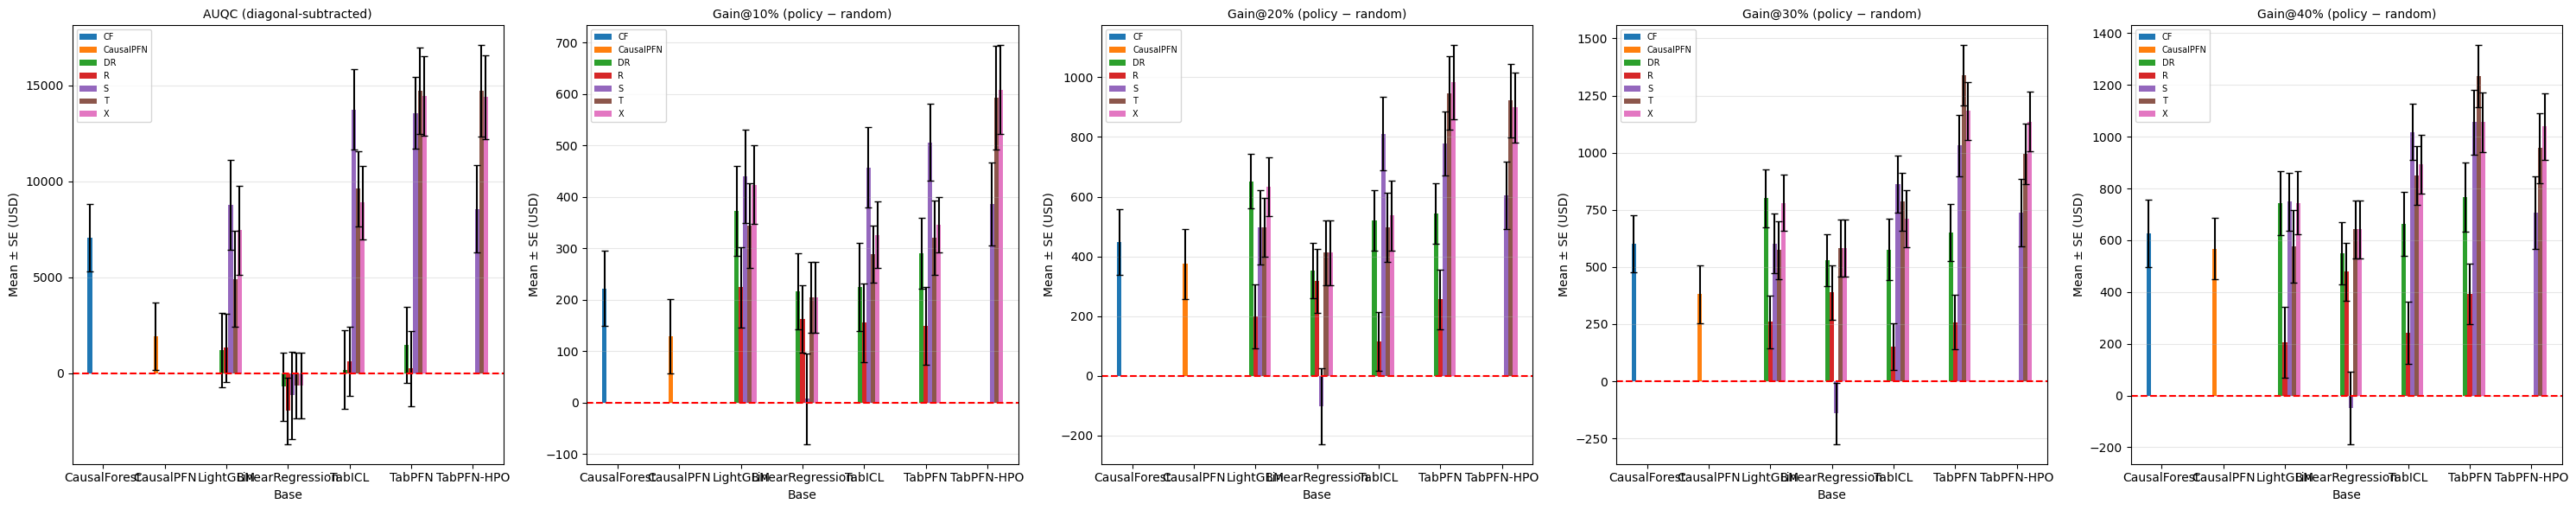

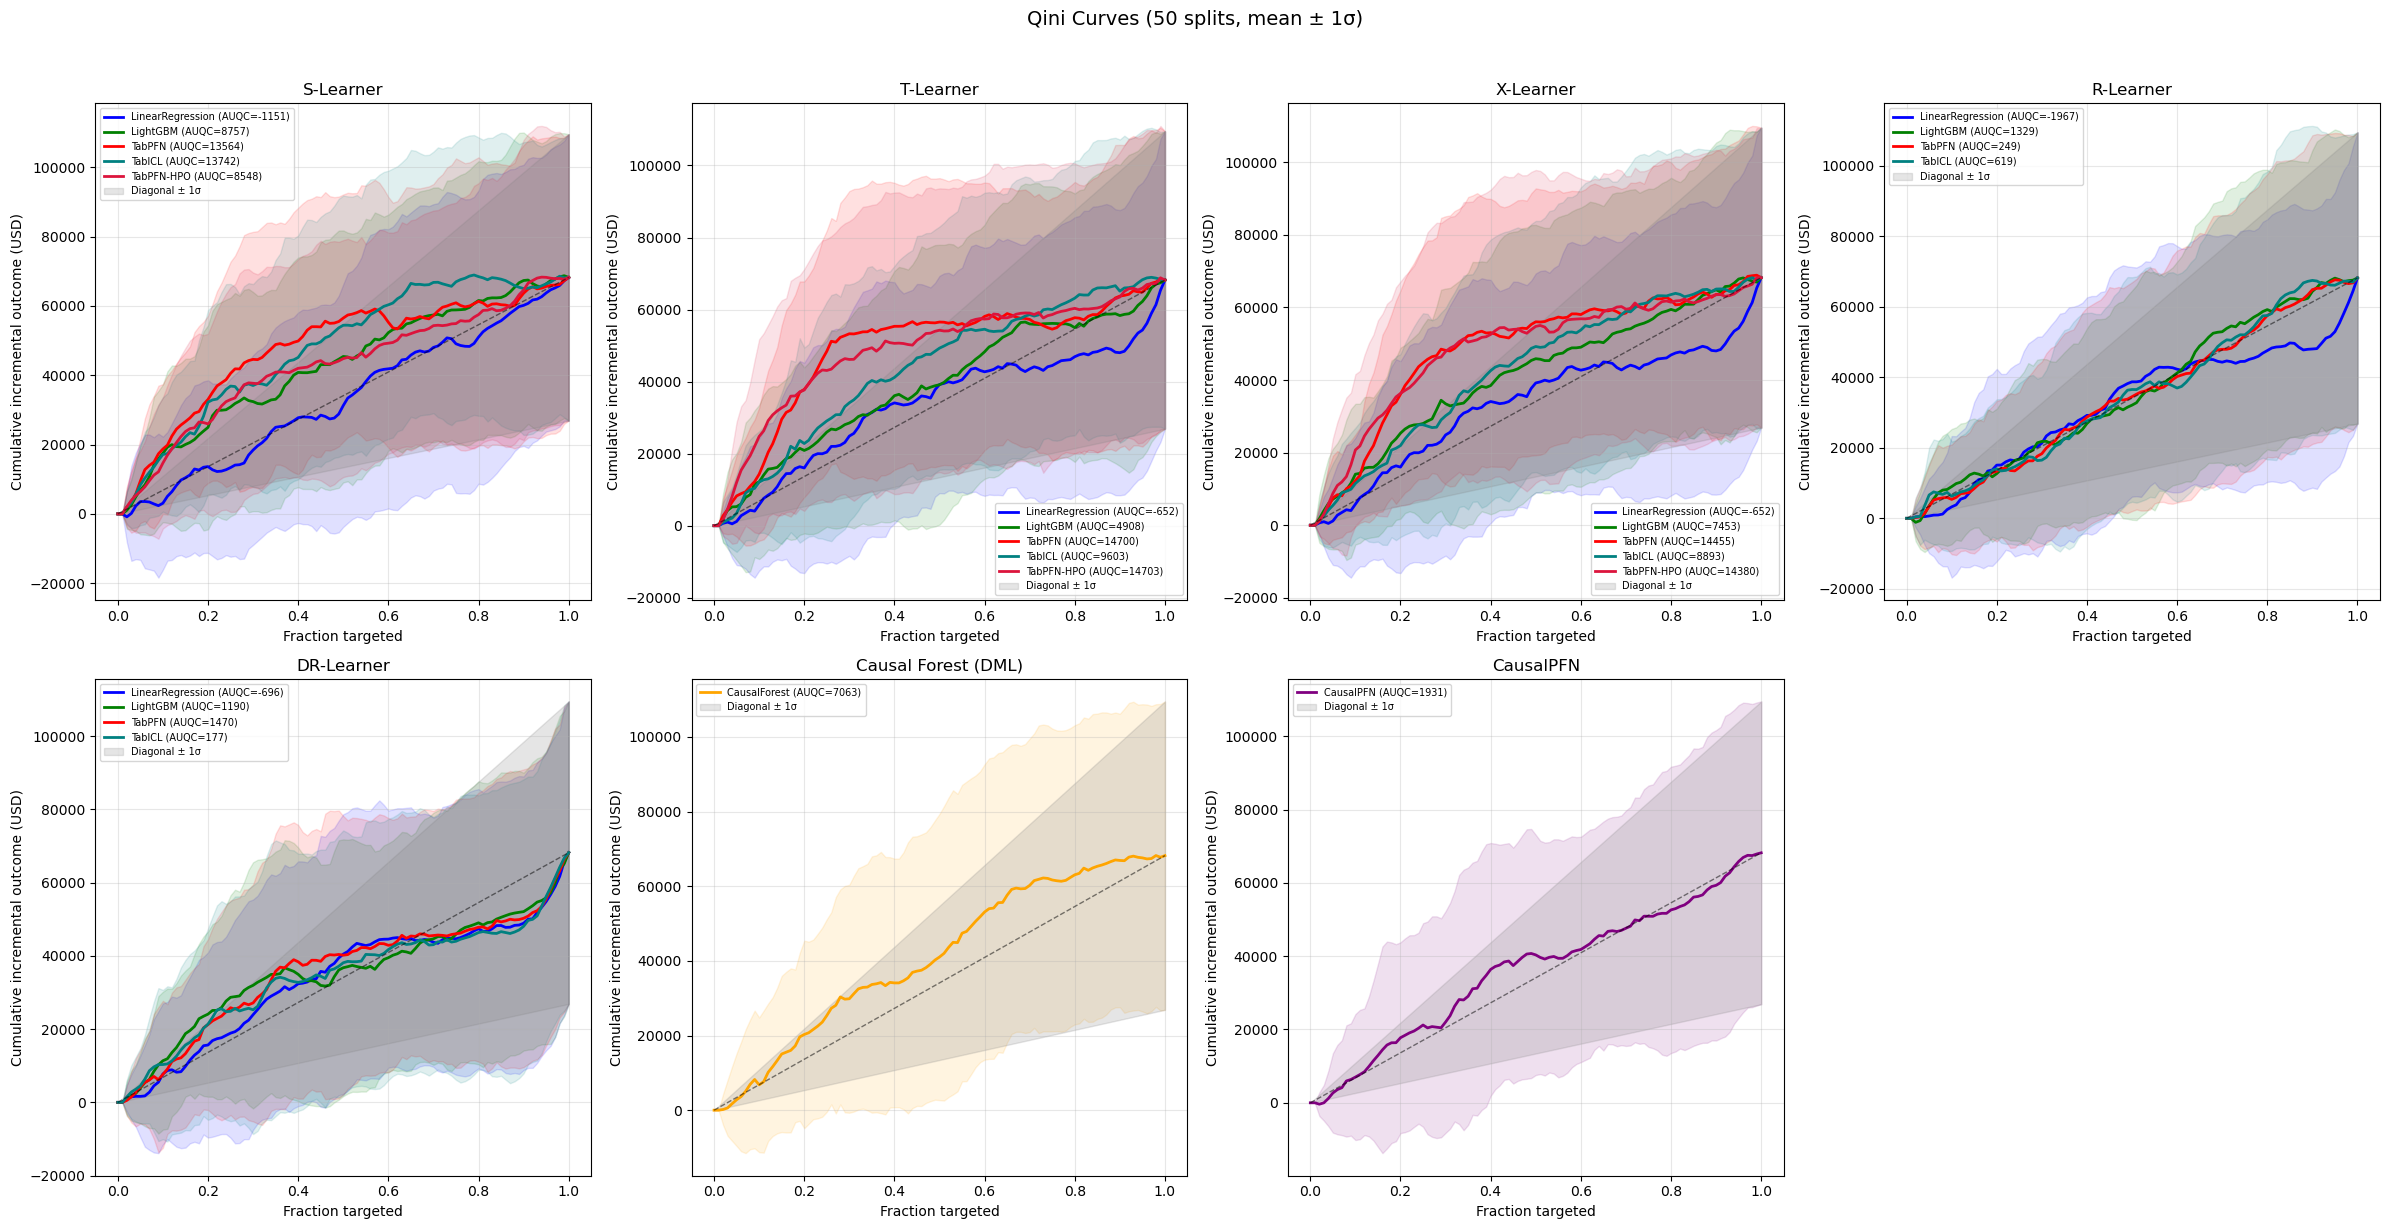

In [12]:
# --- Aggregate ---
STANDALONE_MODELS = {'CausalPFN': 'CausalPFN', 'CF': 'CausalForest'}

rows = []
for meta in META_LEARNERS:
    if meta in STANDALONE_MODELS:
        model_list = [STANDALONE_MODELS[meta]]
    else:
        # Include TabPFN-HPO only for S, T, X learners
        model_list = BASE_MODELS + (['TabPFN-HPO'] if meta in HPO_LEARNERS else [])
    for name in model_list:
        d = results[meta][name]
        if not d['auqc']:
            continue
        row = {'Meta': meta, 'Base': name}

        def agg(vals, label):
            arr = np.array(vals, dtype=float)
            valid = arr[~np.isnan(arr)]
            nv = len(valid)
            row[f'{label} Mean'] = np.nanmean(arr) if nv > 0 else np.nan
            row[f'{label} SE'] = np.nanstd(valid, ddof=1) / np.sqrt(nv) if nv > 1 else np.nan
            row[f'{label} N'] = nv
            if label == 'AUQC' and nv > 1:
                mean = np.nanmean(valid)
                se = np.nanstd(valid, ddof=1) / np.sqrt(nv)
                tcrit = st.t.ppf(0.975, df=nv - 1)
                ci_lo, ci_hi = mean - tcrit * se, mean + tcrit * se
                row[f'{label} CI'] = f"[{ci_lo:.4f}, {ci_hi:.4f}]"
                row[f'{label} Sig'] = '*' if ci_lo > 0 or ci_hi < 0 else ''
            return row

        agg(d['auqc'], 'AUQC')
        for k in TOP_K_PERCENTAGES:
            agg(d[f'gain_{k}'], f'Gain@{k}%')

        rows.append(row)

df = pd.DataFrame(rows)

# Sort by AUQC Mean descending (best first)
df = df.sort_values('AUQC Mean', ascending=False).reset_index(drop=True)

# --- Display: AUQC ---
print("=" * 110)
print(f"RESULTS ACROSS {N_SPLITS} SPLITS (mean ± SE) — ranked by AUQC")
print("=" * 110)
print("AUQC is diagonal-subtracted: expected value under random model is 0 by construction.")

auqc_cols = ['Meta', 'Base', 'AUQC Mean', 'AUQC SE', 'AUQC CI', 'AUQC Sig']
print("\n--- AUQC (diagonal-subtracted) ---")
print(df[auqc_cols].to_string(index=False, float_format='%.4f'))

# --- Display: Policy Gains ---
for k in TOP_K_PERCENTAGES:
    gain_cols = ['Meta', 'Base', f'Gain@{k}% Mean', f'Gain@{k}% SE']
    existing = [c for c in gain_cols if c in df.columns]
    df_k = df.sort_values(f'Gain@{k}% Mean', ascending=False).reset_index(drop=True)
    print(f"\n--- Policy Gain @{k}% (ranked) ---")
    print(df_k[existing].to_string(index=False, float_format='%.2f'))

# --- Bar charts ---
n_bars = 1 + len(TOP_K_PERCENTAGES)
fig, axes = plt.subplots(1, n_bars, figsize=(6 * n_bars, 6))

# AUQC bar chart
ax = axes[0]
plot_data = df.pivot(index='Base', columns='Meta', values='AUQC Mean')
plot_err = df.pivot(index='Base', columns='Meta', values='AUQC SE')
plot_data.plot(kind='bar', yerr=plot_err, ax=ax, capsize=3, rot=0)
ax.set_title('AUQC (diagonal-subtracted)', fontsize=10)
ax.set_ylabel('Mean ± SE (USD)')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=7, loc='best')

# Gain@k% bars
for i, k in enumerate(TOP_K_PERCENTAGES):
    ax = axes[i + 1]
    plot_data = df.pivot(index='Base', columns='Meta', values=f'Gain@{k}% Mean')
    plot_err = df.pivot(index='Base', columns='Meta', values=f'Gain@{k}% SE')
    plot_data.plot(kind='bar', yerr=plot_err, ax=ax, capsize=3, rot=0)
    ax.set_title(f'Gain@{k}% (policy − random)', fontsize=10)
    ax.set_ylabel('Mean ± SE (USD)')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=7, loc='best')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'bar_charts.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Qini Curves: 2x4 grid ---
x_grid = np.linspace(0, 1, N_GRID)
colors = {'LinearRegression': 'blue', 'LightGBM': 'green', 'TabPFN': 'red',
          'TabPFN-HPO': 'crimson', 'TabICL': 'teal', 'CausalForest': 'orange', 'CausalPFN': 'purple'}

# --- Analytical diagonal baseline band ---
# G(1) is a property of (T_test, Y_test) only — identical across all models on the same split.
# Use stored g1 values from S/LightGBM (always present) so the band reflects only
# split-to-split variance in G(1), not model variance.
_g1_per_split = results['S']['LightGBM']['g1']
_all_diag = np.array([x_grid * g1 for g1 in _g1_per_split])
diag_mean = _all_diag.mean(axis=0)
diag_std = _all_diag.std(axis=0)

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for idx, meta in enumerate(['S', 'T', 'X', 'R', 'DR']):
    ax = axes[idx]
    base_list = BASE_MODELS + (['TabPFN-HPO'] if meta in HPO_LEARNERS else [])
    for base in base_list:
        curves_arr = qini_curves[meta][base]
        if curves_arr:
            c = np.array(curves_arr)
            m, s = c.mean(axis=0), c.std(axis=0)
            auqc_mean = np.mean(results[meta][base]['auqc'])
            ax.plot(x_grid, m, color=colors[base], linewidth=2,
                    label=f'{base} (AUQC={auqc_mean:.0f})')
            ax.fill_between(x_grid, m - s, m + s, color=colors[base], alpha=0.12)
    ax.fill_between(x_grid, diag_mean - diag_std, diag_mean + diag_std, color='gray', alpha=0.2, label='Diagonal ± 1σ')
    ax.plot(x_grid, diag_mean, 'k--', linewidth=1, alpha=0.5)
    ax.set_title(f'{meta}-Learner')
    ax.set_xlabel('Fraction targeted')
    ax.set_ylabel('Cumulative incremental outcome (USD)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

ax = axes[5]
curves_arr = qini_curves['CF']['CausalForest']
if curves_arr:
    c = np.array(curves_arr)
    m, s = c.mean(axis=0), c.std(axis=0)
    auqc_mean = np.mean(results['CF']['CausalForest']['auqc'])
    ax.plot(x_grid, m, color=colors['CausalForest'], linewidth=2,
            label=f'CausalForest (AUQC={auqc_mean:.0f})')
    ax.fill_between(x_grid, m - s, m + s, color=colors['CausalForest'], alpha=0.12)
ax.fill_between(x_grid, diag_mean - diag_std, diag_mean + diag_std, color='gray', alpha=0.2, label='Diagonal ± 1σ')
ax.plot(x_grid, diag_mean, 'k--', linewidth=1, alpha=0.5)
ax.set_title('Causal Forest (DML)')
ax.set_xlabel('Fraction targeted')
ax.set_ylabel('Cumulative incremental outcome (USD)')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

ax = axes[6]
curves_arr = qini_curves['CausalPFN']['CausalPFN']
if curves_arr:
    c = np.array(curves_arr)
    m, s = c.mean(axis=0), c.std(axis=0)
    auqc_mean = np.mean(results['CausalPFN']['CausalPFN']['auqc'])
    ax.plot(x_grid, m, color=colors['CausalPFN'], linewidth=2,
            label=f'CausalPFN (AUQC={auqc_mean:.0f})')
    ax.fill_between(x_grid, m - s, m + s, color=colors['CausalPFN'], alpha=0.12)
ax.fill_between(x_grid, diag_mean - diag_std, diag_mean + diag_std, color='gray', alpha=0.2, label='Diagonal ± 1σ')
ax.plot(x_grid, diag_mean, 'k--', linewidth=1, alpha=0.5)
ax.set_title('CausalPFN')
ax.set_xlabel('Fraction targeted')
ax.set_ylabel('Cumulative incremental outcome (USD)')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

axes[7].set_visible(False)

plt.suptitle(f'Qini Curves ({N_SPLITS} splits, mean ± 1σ)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'qini_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
